# MIL v5.3 — Interpretability & Sensitivity Analysis

**Objetivo**: Entender *por qué* el modelo MIL v5.3 (NTv3 encoder + XGBoost) saca las métricas que saca, y qué características moleculares confieren resistencia a ertapenem en *K. pneumoniae*.

## Análisis incluidos

| # | Análisis | Motivación |
|---|----------|-----------|
| A | **Sensitivity Analysis** (Carlos Oscar) | Qué features/genes confieren resistencia según el modelo |
| B | **False Negative Profiling** (Hanqun) | Análisis de aislados que el modelo falla en clasificar como R |
| C | **Attention Head Specialization** | Si las 4 cabezas capturan mecanismos distintos (KPC, efflux, porinas…) |
| D | **SHAP + Gene Backtracking** | Top dimensiones del embedding → genes responsables → BLAST |
| E | **Threshold Calibration** | Curva PR, análisis de umbrales clínicos, Brier Score |

> **Prerequisito**: El modelo `modelo_MIL_v5.1_best_auc.pth` y `modelo_xgboost_v5.3.pkl` deben estar en Google Drive bajo `RUTA_BASE`.

## Celda 0 — Anti-sueño y montar Drive

In [ ]:
try:
    from IPython.display import Javascript, display
    display(Javascript('''function ClickConnect(){document.querySelector("colab-toolbar-button#connect")?.click();document.querySelector("colab-dialog.yes-no-dialog paper-button#ok")?.click();}setInterval(ClickConnect,60000);'''))
    print("Anti-sueño activado")
    from google.colab import drive
    drive.mount("../data")
    IN_COLAB = True
    print("✅ Google Colab detectado y Drive montado.")
except Exception:
    IN_COLAB = False
    print("ℹ️ Entorno local detectado (no Google Colab). Omitiendo montaje de Drive.")


<IPython.core.display.Javascript object>

Anti-sueño activado
Mounted at ../data


## Celda 1 — Instalar dependencias

In [ ]:
!pip install -q transformers xgboost shap captum biopython joblib scikit-learn matplotlib seaborn umap-learn
print("Dependencias listas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.5 MB/s eta 0:00:00
Dependencias listas


## Celda 2 — Login HuggingFace

In [ ]:
import os
from huggingface_hub import login

# Autenticación con Hugging Face (necesario para descargar modelos)
# Utiliza la variable de entorno HF_TOKEN si está configurada, o solicita login interactivo
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token)
else:
    login()


## Celda 3 — Configuración Global

In [ ]:
import os
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────────────────
if 'IN_COLAB' in locals() and IN_COLAB:
    RUTA_BASE        = "../data"
else:
    REPO_ROOT = Path(os.getcwd()).resolve()
    if REPO_ROOT.name == 'notebooks':
        REPO_ROOT = REPO_ROOT.parent
    RUTA_BASE = str(REPO_ROOT)

def first_existing(paths, default):
    for p in paths:
        if os.path.exists(p): return p
    return default

RUTA_TRAIN       = first_existing([f"{RUTA_BASE}/dataset_limpio/train_por_cepa.csv", f"{RUTA_BASE}/data/train_por_cepa.csv"], f"{RUTA_BASE}/data/train_por_cepa.csv")
RUTA_VAL         = first_existing([f"{RUTA_BASE}/dataset_limpio/val_por_cepa.csv", f"{RUTA_BASE}/data/val_por_cepa.csv"], f"{RUTA_BASE}/data/val_por_cepa.csv")
RUTA_MODELO_V51  = first_existing([f"{RUTA_BASE}/modelo_MIL_v5.1_best_auc.pth", f"{RUTA_BASE}/models/modelo_MIL_v5.1_best_auc.pth"], f"{RUTA_BASE}/modelo_MIL_v5.1_best_auc.pth")
RUTA_XGB         = first_existing([f"{RUTA_BASE}/modelo_xgboost_v5.3.pkl", f"{RUTA_BASE}/models/modelo_xgboost_v5.3.pkl"], f"{RUTA_BASE}/modelo_xgboost_v5.3.pkl")
RUTA_SALIDA      = f"{RUTA_BASE}/results/analisis_interpretabilidad_v5.3" if not ('IN_COLAB' in locals() and IN_COLAB) else f"{RUTA_BASE}/analisis_interpretabilidad_v5.3"
os.makedirs(RUTA_SALIDA, exist_ok=True)

# ─── MODELO ───────────────────────────────────────────────────────────────────
MODEL_NAME   = "InstaDeepAI/NTV3_100M_post"
SPECIES_ID   = 6
MAX_SEQ_LEN  = 512
HIDDEN_DIM   = 128
NUM_HEADS    = 4

# ─── FOCAL LOSS (mismos hiper que v5.1) ───────────────────────────────────────
FOCAL_ALPHA  = 0.55
FOCAL_GAMMA  = 2.0
EMBED_DROPOUT = 0.15
SUB_BATCH    = 64

KEYWORDS_CARB = ["carbapenem", "beta-lactam", "OXA", "KPC", "NDM", "VIM", "IMP", "GES"]

print("Configuración lista")
print(f"  Salidas → {RUTA_SALIDA}")


Configuración lista
  Salidas → ../results


## Celda 4 — Arquitectura NTv3MultiHeadMIL (idéntica a v5.3)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from transformers import AutoModel, AutoTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, brier_score_loss
)
from tqdm.auto import tqdm
import joblib
import gc

matplotlib.rcParams["figure.dpi"] = 130
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU: {props.name} — VRAM: {props.total_memory/1024**3:.1f} GB")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print("Tokenizador cargado")


class FocalLoss(nn.Module):
    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        alpha_t = torch.where(
            targets == 1,
            torch.tensor(self.alpha, device=logits.device),
            torch.tensor(1 - self.alpha, device=logits.device)
        )
        return (alpha_t * (1 - pt) ** self.gamma * ce).mean()


class NTv3MultiHeadMIL(nn.Module):
    """NTv3 (100M) + Multi-Head Attention MIL — arquitectura v5.1/v5.3."""

    def __init__(self, model_name, hidden_dim=HIDDEN_DIM,
                 num_heads=NUM_HEADS, embed_dropout=EMBED_DROPOUT):
        super().__init__()
        self.ntv3 = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.layer_norm    = nn.LayerNorm(768)
        self.embed_dropout = nn.Dropout(embed_dropout)
        self.attention_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(768, hidden_dim), nn.Tanh(),
                nn.Dropout(0.1), nn.Linear(hidden_dim, 1)
            ) for _ in range(num_heads)
        ])
        self.projection = nn.Linear(768 * num_heads, 768)
        self.proj_norm  = nn.LayerNorm(768)
        self.classifier = nn.Linear(768, 2)
        self.dropout    = nn.Dropout(0.1)

    def encode_genes(self, input_ids, attention_mask, species_ids):
        out = self.ntv3(
            input_ids=input_ids,
            attention_mask=attention_mask,
            species_ids=species_ids,
            output_hidden_states=True
        )
        emb = out.hidden_states[-1][:, 0, :]
        emb = self.layer_norm(emb)
        emb = self.embed_dropout(emb)
        return emb

    def classify(self, gene_embeddings):
        head_contexts, attn_weights_per_head = [], []
        for attn_net in self.attention_heads:
            scores  = attn_net(gene_embeddings)
            weights = torch.softmax(scores, dim=0)
            context = (weights * gene_embeddings).sum(0)
            head_contexts.append(context)
            attn_weights_per_head.append(weights)
        multi_context = torch.cat(head_contexts, dim=0)
        genome_emb    = self.proj_norm(self.projection(multi_context))
        logits        = self.classifier(self.dropout(genome_emb.unsqueeze(0)))
        return logits, attn_weights_per_head


modelo = NTv3MultiHeadMIL(MODEL_NAME).to(device)
print(f"Modelo instanciado — {sum(p.numel() for p in modelo.parameters() if p.requires_grad)/1e6:.1f}M parámetros")

Dispositivo: cuda
  GPU: Tesla T4 — VRAM: 14.6 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_ntv3_posttrained.py: 0.00B [00:00, ?B/s]

configuration_ntv3_pretrained.py: 0.00B [00:00, ?B/s]

...

modeling_ntv3_pretrained.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- modeling_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- modeling_ntv3_posttrained.py
- modeling_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/480M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/370 [00:00<?, ?it/s]

Modelo instanciado — 122.8M parámetros


## Celda 5 — Cargar pesos del encoder v5.1 y XGBoost v5.3

In [ ]:
# ─── Encoder NTv3 (v5.1) ──────────────────────────────────────────────────────
ckpt = torch.load(RUTA_MODELO_V51, map_location=device, weights_only=False)
modelo.load_state_dict(ckpt["model_state_dict"], strict=False)
modelo.eval()
print(f"Encoder v5.1 cargado — época {ckpt['epoch']} — AUC val: {ckpt['auc']:.4f}")

# ─── XGBoost (v5.3) ───────────────────────────────────────────────────────────
clf_xgb = joblib.load(RUTA_XGB)
print("XGBoost v5.3 cargado")

Encoder v5.1 cargado — época 11 — AUC val: 0.9182
XGBoost v5.3 cargado


## Celda 6 — Cargar datos y construir bags

In [ ]:
train_df = pd.read_csv(RUTA_TRAIN)
val_df   = pd.read_csv(RUTA_VAL)

HAS_DRUG_CLASS = "Drug Class" in train_df.columns
print(f"Columna Drug Class: {HAS_DRUG_CLASS}")
print(f"Train: {len(train_df):,} seqs | {train_df['genome_id'].nunique()} cepas")
print(f"Val  : {len(val_df):,} seqs | {val_df['genome_id'].nunique()} cepas")

MAX_GENES = 50

def crear_bags(df, max_genes=MAX_GENES):
    patron = "|".join(KEYWORDS_CARB)
    bags = []
    for genome_id, grp in df.groupby("genome_id"):
        label = int(grp["label"].iloc[0])
        seqs  = grp["sequence"].tolist()
        if HAS_DRUG_CLASS and len(seqs) > max_genes:
            es_rel = grp["Drug Class"].str.contains(patron, case=False, na=False)
            rel    = grp[es_rel]["sequence"].tolist()
            otros  = grp[~es_rel]["sequence"].tolist()
            if len(rel) >= max_genes:
                idx  = np.random.choice(len(rel), max_genes, replace=False)
                seqs = [rel[i] for i in idx]
            else:
                cupo = max_genes - len(rel)
                idx  = np.random.choice(len(otros), min(cupo, len(otros)), replace=False)
                seqs = rel + [otros[i] for i in idx]
        elif len(seqs) > max_genes:
            idx  = np.random.choice(len(seqs), max_genes, replace=False)
            seqs = [seqs[i] for i in idx]
        bags.append({"sequences": seqs, "label": label, "genome_id": genome_id})
    return bags


class BagDataset(Dataset):
    def __init__(self, bags, tokenizer, max_len=MAX_SEQ_LEN, species_id=SPECIES_ID):
        self.bags, self.tokenizer = bags, tokenizer
        self.max_len, self.species_id = max_len, species_id

    def __len__(self): return len(self.bags)

    def __getitem__(self, idx):
        bag = self.bags[idx]
        tok = self.tokenizer(
            bag["sequences"], padding="max_length", truncation=True,
            max_length=self.max_len, return_tensors="pt"
        )
        mask = tok.get("attention_mask", torch.ones_like(tok["input_ids"]))
        return {
            "input_ids"    : tok["input_ids"],
            "attention_mask": mask,
            "species_ids"  : torch.tensor(self.species_id, dtype=torch.long),
            "label"        : torch.tensor(bag["label"], dtype=torch.long),
            "genome_id"    : bag["genome_id"]
        }


train_bags   = crear_bags(train_df)
val_bags     = crear_bags(val_df)
val_dataset  = BagDataset(val_bags, tokenizer)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
train_dataset = BagDataset(train_bags, tokenizer)
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False)

print(f"Bags train: {len(train_bags)} | Bags val: {len(val_bags)}")
print("DataLoaders creados")

Columna Drug Class: False
Train: 17,112 seqs | 3078 cepas
Val  : 4,504 seqs | 770 cepas
Bags train: 3078 | Bags val: 770
DataLoaders creados


## Celda 7 — Helper: encode_bag y extraer_embeddings_full
Extrae embeddings **y** metadatos de atención en un solo pass.

In [ ]:
def encode_bag(model, input_ids, attention_mask, species_id_val, sub_batch=SUB_BATCH):
    embeddings = []
    n = input_ids.size(0)
    for s in range(0, n, sub_batch):
        e   = min(s + sub_batch, n)
        sp  = torch.full((e - s,), species_id_val, dtype=torch.long, device=device)
        emb = model.encode_genes(input_ids[s:e], attention_mask[s:e], sp)
        embeddings.append(emb)
    return torch.cat(embeddings, dim=0)


def extraer_full(model, loader, bags_list, desc="Extrayendo"):
    """
    Devuelve:
      X           : np.array [N_isolates, 768]  embeddings finales
      y           : np.array [N_isolates]       labels reales
      genome_ids  : list[str]
      attn_records: list[dict]  — metadatos de atención por aislado
    """
    model.eval()
    dict_bags = {b["genome_id"]: b["sequences"] for b in bags_list}
    X, y, gids, attn_records = [], [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            ids   = batch["input_ids"].squeeze(0).to(device)
            mask  = batch["attention_mask"].squeeze(0).to(device)
            sp    = batch["species_ids"].item()
            label = batch["label"].item()
            gid   = batch["genome_id"][0]
            seqs  = dict_bags.get(gid, [])

            with torch.amp.autocast('cuda'):
                embs = encode_bag(model, ids, mask, sp)  # [N_genes, 768]
                N    = embs.size(0)

                head_contexts, head_weights_list = [], []
                head_max, head_var = [], []
                for attn_net in model.attention_heads:
                    scores  = attn_net(embs)
                    weights = torch.softmax(scores, dim=0)  # [N, 1]
                    context = (weights * embs).sum(0)
                    head_contexts.append(context)
                    head_weights_list.append(weights.cpu().numpy())
                    head_max.append(weights.max().item())
                    head_var.append(weights.var(unbiased=False).item() if N > 1 else 0.0)

                multi_context = torch.cat(head_contexts, dim=0)
                genome_emb    = model.proj_norm(model.projection(multi_context))  # [768]

            # Top-gene por cabeza (índice del gen con mayor peso)
            top_gene_per_head = [
                int(np.argmax(w)) for w in head_weights_list
            ]
            top_gene_seqs = [
                (seqs[i][:60] if i < len(seqs) else "?") for i in top_gene_per_head
            ]

            attn_records.append({
                "genome_id"        : gid,
                "label"            : label,
                "dominant_head"    : int(np.argmax(head_max)),
                "head_max_weights" : head_max,
                "head_var_weights" : head_var,
                "top_gene_per_head": top_gene_per_head,
                "top_gene_seqs"    : top_gene_seqs,
                "n_genes"          : N,
            })
            X.append(genome_emb.cpu().numpy())
            y.append(label)
            gids.append(gid)

    return np.array(X), np.array(y), gids, attn_records


print("Helpers definidos")

Helpers definidos


## Celda 8 — Extraer embeddings (val + train)

In [ ]:
print("Extrayendo embeddings de validación...")
X_val, y_val, gids_val, attn_val = extraer_full(modelo, val_loader, val_bags, "Val")

print("\nExtrayendo embeddings de entrenamiento...")
X_train, y_train, gids_train, attn_train = extraer_full(modelo, train_loader, train_bags, "Train")

print(f"\nEmb val  : {X_val.shape}")
print(f"Emb train: {X_train.shape}")

# Predicciones XGBoost
y_pred_val   = clf_xgb.predict(X_val)
y_score_val  = clf_xgb.predict_proba(X_val)[:, 1]
auc_val      = roc_auc_score(y_val, y_score_val)

print(f"\n=== MÉTRICAS CONFIRMADAS — MIL v5.3 ===")
print(classification_report(y_val, y_pred_val, target_names=["S", "R"]))
print(f"ROC-AUC : {auc_val:.4f}")
print(f"PR-AUC  : {average_precision_score(y_val, y_score_val):.4f}")
print(f"Brier   : {brier_score_loss(y_val, y_score_val):.4f}")

Extrayendo embeddings de validación...


Val:   0%|          | 0/770 [00:00<?, ?it/s]


Extrayendo embeddings de entrenamiento...


Train:   0%|          | 0/3078 [00:00<?, ?it/s]


Emb val  : (770, 768)
Emb train: (3078, 768)

=== MÉTRICAS CONFIRMADAS — MIL v5.3 ===
              precision    recall  f1-score   support

           S       0.90      0.93      0.91       480
           R       0.88      0.82      0.85       290

    accuracy                           0.89       770
   macro avg       0.89      0.88      0.88       770
weighted avg       0.89      0.89      0.89       770

ROC-AUC : 0.9626
PR-AUC  : 0.9475
Brier   : 0.0732


---
# ═══════════════════════════════════════════════════
# ANÁLISIS A — Sensitivity Analysis
# (Idea Carlos Oscar Sorzano)
# Qué características confieren resistencia
# ═══════════════════════════════════════════════════

### A1 — SHAP global sobre XGBoost (top dimensiones del embedding)

Calculando SHAP TreeExplainer...

Top 5 dimensiones más predictivas del embedding (SHAP):
  #1 → Dim 550  |  Mean |SHAP|: 0.79004
  #2 → Dim 755  |  Mean |SHAP|: 0.26566
  #3 → Dim 737  |  Mean |SHAP|: 0.19958
  #4 → Dim 267  |  Mean |SHAP|: 0.16028
  #5 → Dim 103  |  Mean |SHAP|: 0.14392


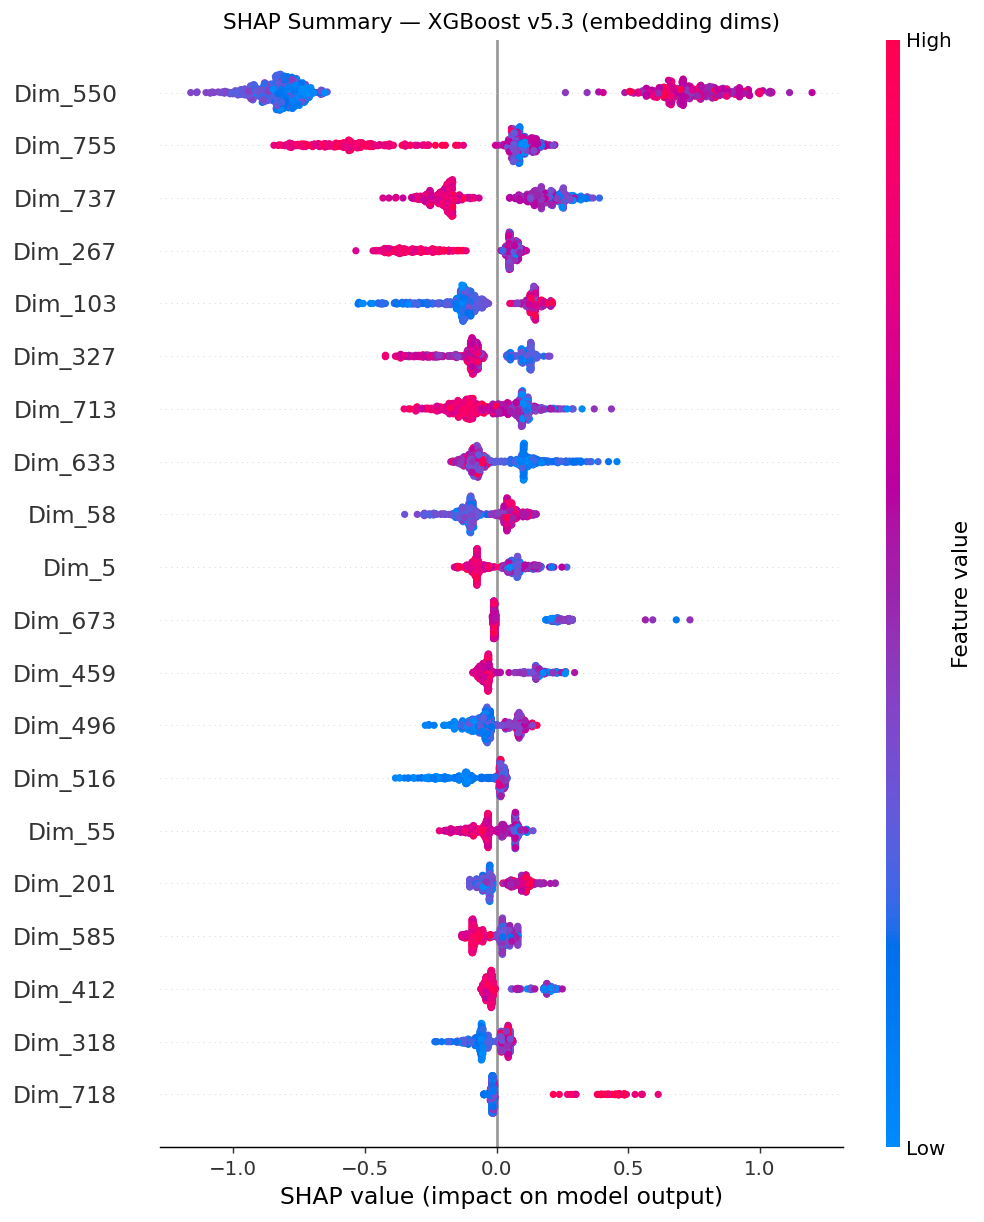

Guardado: shap_summary_global.png


In [ ]:
import shap

print("Calculando SHAP TreeExplainer...")
explainer    = shap.TreeExplainer(clf_xgb)
shap_values  = explainer.shap_values(X_val)  # [N_isolates, 768]

shap_importance = np.abs(shap_values).mean(axis=0)  # [768]
top_dims_idx    = np.argsort(shap_importance)[::-1][:20]  # Top 20 dims
TOP_K_DIMS      = 5  # Para análisis profundo
top_dims        = top_dims_idx[:TOP_K_DIMS]

print(f"\nTop {TOP_K_DIMS} dimensiones más predictivas del embedding (SHAP):")
for i, d in enumerate(top_dims):
    print(f"  #{i+1} → Dim {d:3d}  |  Mean |SHAP|: {shap_importance[d]:.5f}")

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, max_display=20, show=False,
                  feature_names=[f"Dim_{i}" for i in range(768)])
plt.title("SHAP Summary — XGBoost v5.3 (embedding dims)")
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/shap_summary_global.png", dpi=150)
plt.show()
print(f"Guardado: shap_summary_global.png")

### A2 — Sensitivity Analysis: perturbación de genes
Por cada aislado en validación, enmascaramos (zeroing) cada gen uno por uno y medimos el cambio en la probabilidad predicha de resistencia. Genes cuya eliminación reduce más la prob_R son los más relevantes para la predicción.

In [ ]:
print("=" * 65)
print("SENSITIVITY ANALYSIS — Leave-One-Gene-Out")
print("=" * 65)

dict_bags_val = {b["genome_id"]: b["sequences"] for b in val_bags}
proj_weight   = modelo.projection.weight.detach()  # [768, 768*NUM_HEADS]

sensitivity_records = []

modelo.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Sensitivity (LOGO)"):
        ids   = batch["input_ids"].squeeze(0).to(device)
        mask  = batch["attention_mask"].squeeze(0).to(device)
        sp    = batch["species_ids"].item()
        label = batch["label"].item()
        gid   = batch["genome_id"][0]
        seqs  = dict_bags_val.get(gid, [])

        with torch.amp.autocast('cuda'):
            embs = encode_bag(modelo, ids, mask, sp)  # [N, 768]
            N    = embs.size(0)

            # Embedding baseline (todos los genes)
            head_contexts = []
            for attn_net in modelo.attention_heads:
                w = torch.softmax(attn_net(embs), dim=0)
                head_contexts.append((w * embs).sum(0))
            baseline_emb = modelo.proj_norm(
                modelo.projection(torch.cat(head_contexts))
            ).cpu().numpy()
            prob_base = clf_xgb.predict_proba(baseline_emb.reshape(1, -1))[0, 1]

            # Leave-One-Gene-Out
            for gene_idx in range(N):
                # Mascara: ponemos a cero el gen gene_idx
                mask_embs = embs.clone()
                mask_embs[gene_idx] = 0.0

                head_ctx_loo = []
                for attn_net in modelo.attention_heads:
                    w = torch.softmax(attn_net(mask_embs), dim=0)
                    head_ctx_loo.append((w * mask_embs).sum(0))
                loo_emb = modelo.proj_norm(
                    modelo.projection(torch.cat(head_ctx_loo))
                ).cpu().numpy()
                prob_loo = clf_xgb.predict_proba(loo_emb.reshape(1, -1))[0, 1]

                delta = prob_base - prob_loo  # positivo → gen aumenta prob_R

                seq_full = seqs[gene_idx] if gene_idx < len(seqs) else ""
                sensitivity_records.append({
                    "genome_id"     : gid,
                    "label"         : label,
                    "gene_idx"      : gene_idx,
                    "prob_base"     : prob_base,
                    "prob_loo"      : prob_loo,
                    "delta_prob_R"  : delta,
                    "full_sequence" : seq_full,
                    "seq_snippet"   : seq_full[:60] + "..." if len(seq_full) > 60 else seq_full
                })

df_sens = pd.DataFrame(sensitivity_records)
df_sens.to_csv(f"{RUTA_SALIDA}/sensitivity_LOGO.csv", index=False)
print(f"\nSensitivity table guardada: {len(df_sens)} filas")
print(df_sens[["genome_id","label","gene_idx","delta_prob_R"]].describe())

SENSITIVITY ANALYSIS — Leave-One-Gene-Out


Sensitivity (LOGO):   0%|          | 0/770 [00:00<?, ?it/s]


Sensitivity table guardada: 4502 filas
             label     gene_idx  delta_prob_R
count  4502.000000  4502.000000   4502.000000
mean      0.169480     7.335629      0.011396
std       0.375217     8.134504      0.159296
min       0.000000     0.000000     -0.859060
25%       0.000000     1.000000     -0.001214
50%       0.000000     5.000000      0.000000
75%       0.000000    11.000000      0.000613
max       1.000000    49.000000      0.964825


### A3 — Visualizar Top Genes por Sensibilidad (R vs S)

/tmp/ipykernel_1284/3919261851.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_sens_plot, x="Clase", y="delta_prob_R",
/tmp/ipykernel_1284/3919261851.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


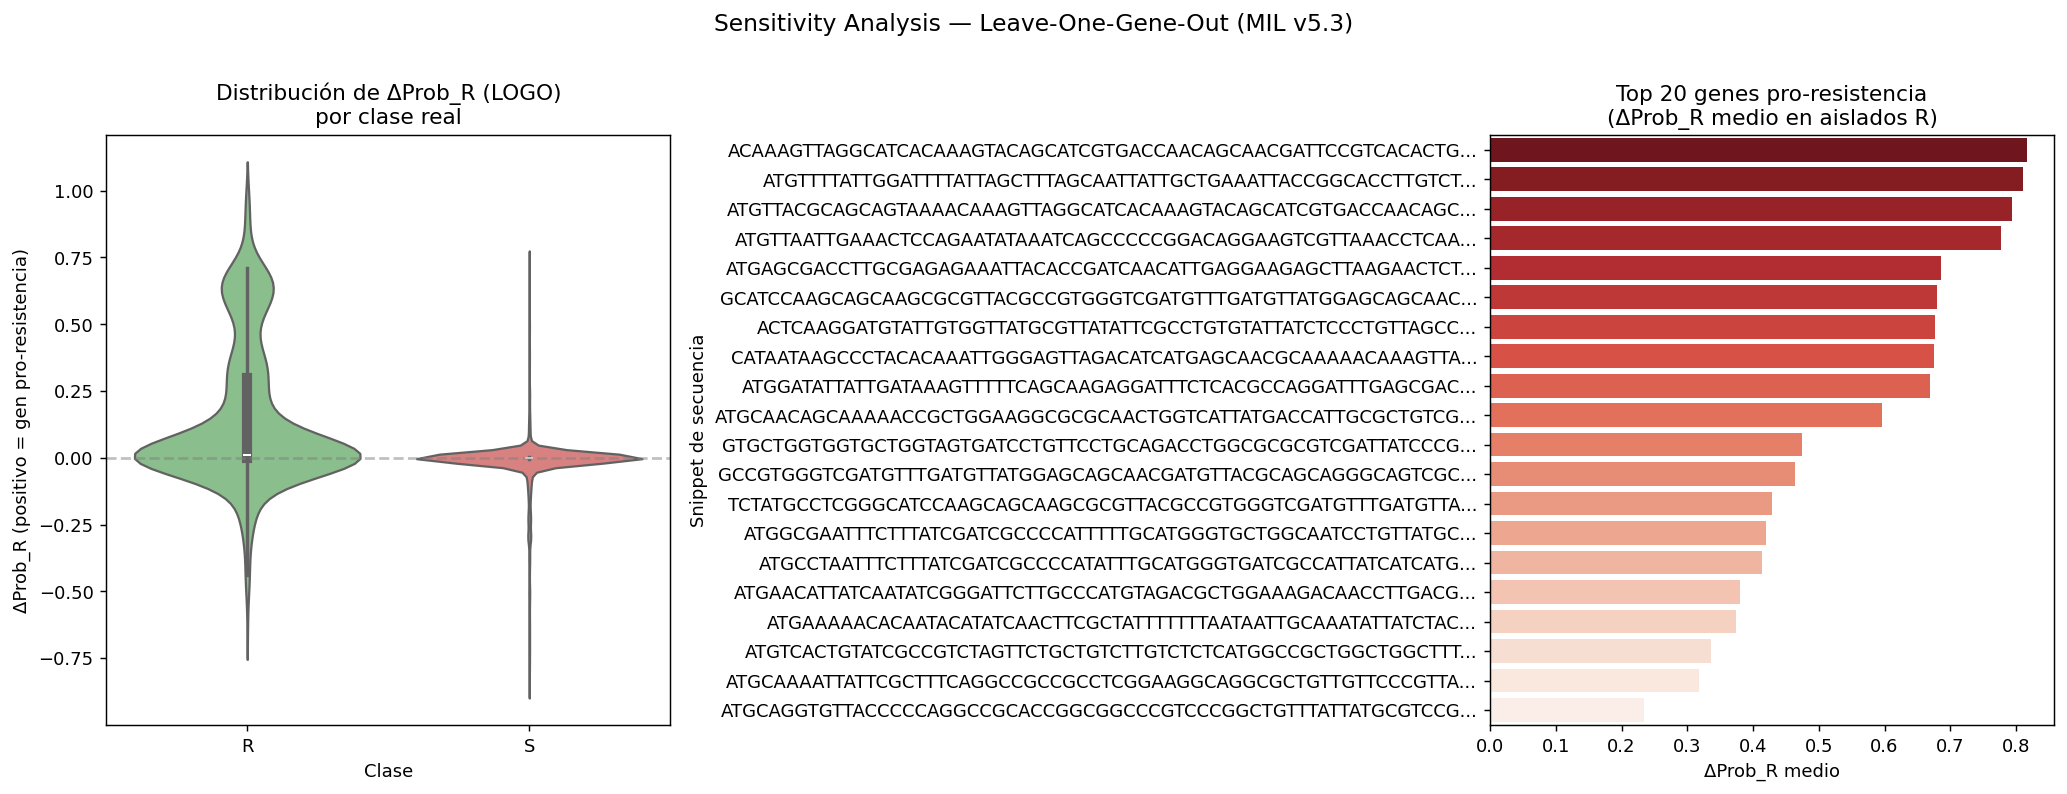

Guardado: sensitivity_LOGO_viz.png

--- Top 10 Genes más influyentes ---
                                                    seq_snippet     mean  count
ACAAAGTTAGGCATCACAAAGTACAGCATCGTGACCAACAGCAACGATTCCGTCACACTG... 0.816912      2
ATGTTTTATTGGATTTTATTAGCTTTAGCAATTATTGCTGAAATTACCGGCACCTTGTCT... 0.809964      2
ATGTTACGCAGCAGTAAAACAAAGTTAGGCATCACAAAGTACAGCATCGTGACCAACAGC... 0.793980      2
ATGTTAATTGAAACTCCAGAATATAAATCAGCCCCCGGACAGGAAGTCGTTAAACCTCAA... 0.776798      2
ATGAGCGACCTTGCGAGAGAAATTACACCGATCAACATTGAGGAAGAGCTTAAGAACTCT... 0.685184      2
GCATCCAAGCAGCAAGCGCGTTACGCCGTGGGTCGATGTTTGATGTTATGGAGCAGCAAC... 0.679780     10
ACTCAAGGATGTATTGTGGTTATGCGTTATATTCGCCTGTGTATTATCTCCCTGTTAGCC... 0.676247      2
CATAATAAGCCCTACACAAATTGGGAGTTAGACATCATGAGCAACGCAAAAACAAAGTTA... 0.675868      6
ATGGATATTATTGATAAAGTTTTTCAGCAAGAGGATTTCTCACGCCAGGATTTGAGCGAC... 0.668715      2
ATGCAACAGCAAAAACCGCTGGAAGGCGCGCAACTGGTCATTATGACCATTGCGCTGTCG... 0.596383      7


In [ ]:
# Top genes cuya eliminación baja más la prob_R (solo en aislados R correctamente predichos)
df_R_correct = df_sens[(df_sens["label"] == 1) & (df_sens["prob_base"] >= 0.5)]

# Genes más sensibles: mayor delta medio en aislados R
top_sens_genes = (
    df_R_correct
    .groupby("seq_snippet")["delta_prob_R"]
    .agg(["mean", "count"])
    .query("count >= 2")  # aparece en al menos 2 aislados
    .sort_values("mean", ascending=False)
    .head(20)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: distribución de delta_prob_R por clase
df_sens_plot = df_sens.copy()
df_sens_plot["Clase"] = df_sens_plot["label"].map({0: "S", 1: "R"})
sns.violinplot(data=df_sens_plot, x="Clase", y="delta_prob_R",
               palette=["#81C784", "#E57373"], ax=axes[0])
axes[0].axhline(0, linestyle="--", color="gray", alpha=0.5)
axes[0].set_title("Distribución de ΔProb_R (LOGO)\npor clase real")
axes[0].set_ylabel("ΔProb_R (positivo = gen pro-resistencia)")

# Panel derecho: top genes más influyentes
if len(top_sens_genes) > 0:
    sns.barplot(
        data=top_sens_genes, x="mean", y="seq_snippet",
        palette="Reds_r", ax=axes[1]
    )
    axes[1].set_title("Top 20 genes pro-resistencia\n(ΔProb_R medio en aislados R)")
    axes[1].set_xlabel("ΔProb_R medio")
    axes[1].set_ylabel("Snippet de secuencia")
else:
    axes[1].text(0.5, 0.5, "No hay genes repetidos suficientes",
                 ha="center", va="center", transform=axes[1].transAxes)

plt.suptitle("Sensitivity Analysis — Leave-One-Gene-Out (MIL v5.3)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/sensitivity_LOGO_viz.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: sensitivity_LOGO_viz.png")

print("\n--- Top 10 Genes más influyentes ---")
print(top_sens_genes.head(10).to_string(index=False))

---
# ═══════════════════════════════════════════════════
# ANÁLISIS B — False Negative Profiling
# (Case study sugerido por Hanqun)
# ═══════════════════════════════════════════════════

### B1 — Construir df_pred con errores clasificados

In [ ]:
df_pred = pd.DataFrame({
    "genome_id"  : gids_val,
    "label_real" : y_val,
    "pred_label" : y_pred_val,
    "prob_R"     : y_score_val,
})
df_pred["error_type"] = "Correct"
df_pred.loc[(df_pred["label_real"]==1) & (df_pred["pred_label"]==0), "error_type"] = "FN (VME)"
df_pred.loc[(df_pred["label_real"]==0) & (df_pred["pred_label"]==1), "error_type"] = "FP (ME)"

n_fn = (df_pred["error_type"]=="FN (VME)").sum()
n_fp = (df_pred["error_type"]=="FP (ME)").sum()
n_ok = (df_pred["error_type"]=="Correct").sum()
print(f"Correctos: {n_ok} | FN (VME): {n_fn} | FP (ME): {n_fp}")
df_pred.to_csv(f"{RUTA_SALIDA}/predictions_val.csv", index=False)
print("Guardado: predictions_val.csv")

Correctos: 685 | FN (VME): 51 | FP (ME): 34
Guardado: predictions_val.csv


### B2 — Prob_R por error type (distribución)

/tmp/ipykernel_1284/1953537777.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


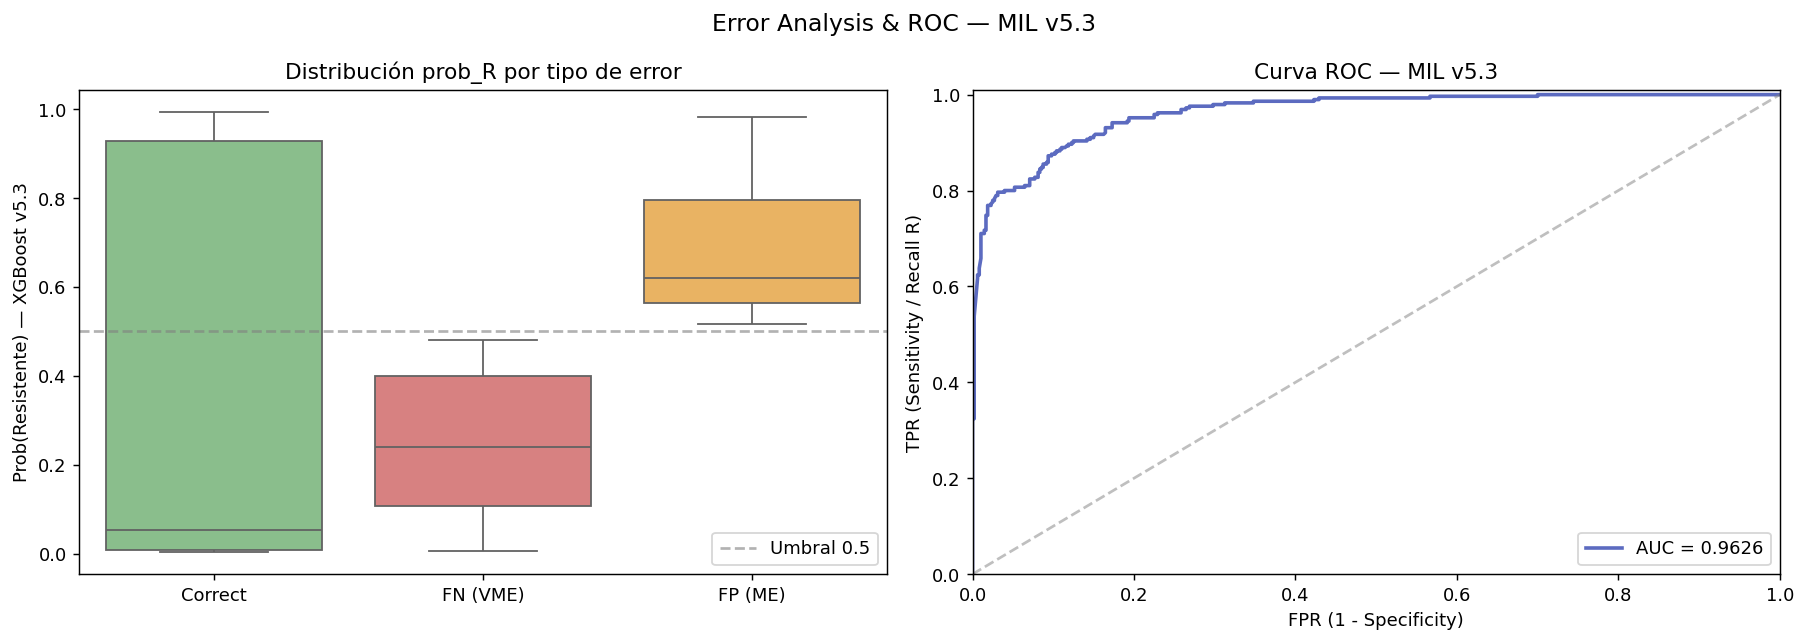

Guardado: error_analysis_roc.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: distribución de prob_R por error type
order = ["Correct", "FN (VME)", "FP (ME)"]
palette = {"Correct": "#81C784", "FN (VME)": "#E57373", "FP (ME)": "#FFB74D"}
sns.boxplot(
    data=df_pred, x="error_type", y="prob_R",
    order=order, palette=palette, ax=axes[0]
)
axes[0].axhline(0.5, linestyle="--", color="gray", alpha=0.6, label="Umbral 0.5")
axes[0].set_title("Distribución prob_R por tipo de error")
axes[0].set_ylabel("Prob(Resistente) — XGBoost v5.3")
axes[0].set_xlabel("")
axes[0].legend()

# Panel B: curva ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_score_val)
axes[1].plot(fpr, tpr, lw=2, color="#5C6BC0", label=f"AUC = {auc_val:.4f}")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
axes[1].set_xlabel("FPR (1 - Specificity)")
axes[1].set_ylabel("TPR (Sensitivity / Recall R)")
axes[1].set_title("Curva ROC — MIL v5.3")
axes[1].legend()
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.01])

plt.suptitle("Error Analysis & ROC — MIL v5.3", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/error_analysis_roc.png", dpi=150)
plt.show()
print("Guardado: error_analysis_roc.png")

### B3 — Análisis de FN: ¿cuántos genes tienen? ¿prob_R cuánto vale?

In [ ]:
# Añadir n_genes al df_pred
attn_df = pd.DataFrame(attn_val)
df_pred_ext = df_pred.merge(
    attn_df[["genome_id","n_genes","dominant_head","head_max_weights","head_var_weights"]],
    on="genome_id", how="left"
)

fn_df = df_pred_ext[df_pred_ext["error_type"] == "FN (VME)"].copy()

print(f"=== FALSE NEGATIVES (VME) — {len(fn_df)} aislados ===")
print(f"  prob_R media  : {fn_df['prob_R'].mean():.3f}")
print(f"  prob_R mediana: {fn_df['prob_R'].median():.3f}")
print(f"  n_genes medio : {fn_df['n_genes'].mean():.1f}")
print()
print("Aislados FN con prob_R más alta (los 'casi detectados'):")
display(fn_df.sort_values("prob_R", ascending=False)[
    ["genome_id","prob_R","n_genes","dominant_head"]
].head(10))

print("\nAislados FN con prob_R más baja (resistencia críptica):")
display(fn_df.sort_values("prob_R")[
    ["genome_id","prob_R","n_genes","dominant_head"]
].head(10))

=== FALSE NEGATIVES (VME) — 51 aislados ===
  prob_R media  : 0.244
  prob_R mediana: 0.239
  n_genes medio : 3.0

Aislados FN con prob_R más alta (los 'casi detectados'):


,genome_id,prob_R,n_genes,dominant_head
129,Kp_ertapenem_R_76w_winter_573_92117,0.480174,10,3
717,R__rgi_Klebsiella_pneumoniae_ertapenem_RESISTA...,0.468131,1,0
19,GCA_002968475.1,0.462825,1,0
34,GCA_014840405.1,0.457268,1,0
155,Kp_ertapenem_R_AR_0044_573_7033,0.449515,1,0
213,Kp_ertapenem_R_KP205_573_78863,0.447536,3,2
262,Kp_ertapenem_R_Kpngiani7132614_573_29924,0.440147,2,2
237,Kp_ertapenem_R_Kpn37_573_81413,0.434063,1,0
143,Kp_ertapenem_R_AN-79_573_83567,0.432362,1,0
71,GCA_024580135.1,0.422737,2,1



Aislados FN con prob_R más baja (resistencia críptica):


,genome_id,prob_R,n_genes,dominant_head
162,Kp_ertapenem_R_C027_573_36695,0.006727,4,0
233,Kp_ertapenem_R_Kpn02028_573_82205,0.009872,15,2
11,GCA_001874715.1,0.016288,16,2
29,GCA_013180465.1,0.016951,1,0
98,Kp_ertapenem_R_26994_6#57_573_66318,0.025594,2,1
253,Kp_ertapenem_R_Kpngiani7132556_573_29995,0.032356,9,1
120,Kp_ertapenem_R_3035_kpn_573_78031,0.043188,1,0
142,Kp_ertapenem_R_AN-78_573_83570,0.068066,8,0
146,Kp_ertapenem_R_AR8217_573_83781,0.071589,1,0
169,Kp_ertapenem_R_CPE_E257_573_81083,0.077486,1,0


### B4 — Threshold sweep: cuántos FN se recuperan bajando el umbral

 Threshold  Recall_R  Spec_S  FN  FP   F1_R
      0.30    0.8966  0.8812  30  57 0.8567
      0.35    0.8828  0.8958  34  50 0.8591
      0.40    0.8690  0.9062  38  45 0.8586
      0.45    0.8379  0.9188  47  39 0.8497
      0.50    0.8241  0.9292  51  34 0.8490
      0.55    0.8069  0.9396  56  29 0.8463
      0.60    0.8000  0.9583  58  20 0.8561
      0.65    0.7966  0.9688  59  15 0.8619
      0.70    0.7828  0.9729  63  13 0.8566


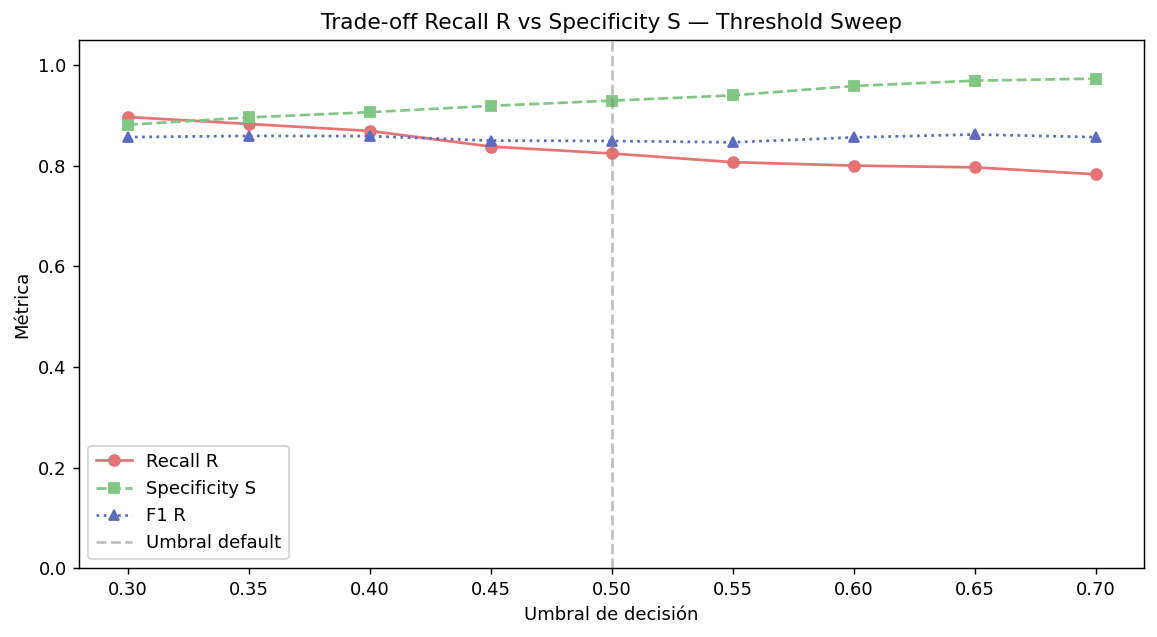

Guardado: threshold_sweep.png


In [ ]:
from sklearn.metrics import confusion_matrix, f1_score

thresholds_sweep = np.arange(0.30, 0.71, 0.05)
results = []
for thr in thresholds_sweep:
    preds = (y_score_val >= thr).astype(int)
    cm    = confusion_matrix(y_val, preds)
    tn, fp, fn, tp = cm.ravel()
    recall_R  = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec_S    = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_R      = f1_score(y_val, preds, pos_label=1, zero_division=0)
    results.append({
        "Threshold": round(thr, 2),
        "Recall_R" : round(recall_R, 4),
        "Spec_S"   : round(spec_S, 4),
        "FN"       : fn,
        "FP"       : fp,
        "F1_R"     : round(f1_R, 4),
    })

df_thr = pd.DataFrame(results)
print(df_thr.to_string(index=False))
df_thr.to_csv(f"{RUTA_SALIDA}/threshold_sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_thr["Threshold"], df_thr["Recall_R"], "o-", label="Recall R", color="#E57373")
ax.plot(df_thr["Threshold"], df_thr["Spec_S"],   "s--", label="Specificity S", color="#81C784")
ax.plot(df_thr["Threshold"], df_thr["F1_R"],     "^:", label="F1 R", color="#5C6BC0")
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral default")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Métrica")
ax.set_title("Trade-off Recall R vs Specificity S — Threshold Sweep")
ax.legend()
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/threshold_sweep.png", dpi=150)
plt.show()
print("Guardado: threshold_sweep.png")

---
# ═══════════════════════════════════════════════════
# ANÁLISIS C — Attention Head Specialization
# ¿Cada cabeza captura un mecanismo distinto?
# ═══════════════════════════════════════════════════

ANÁLISIS C — Attention Head Specialization


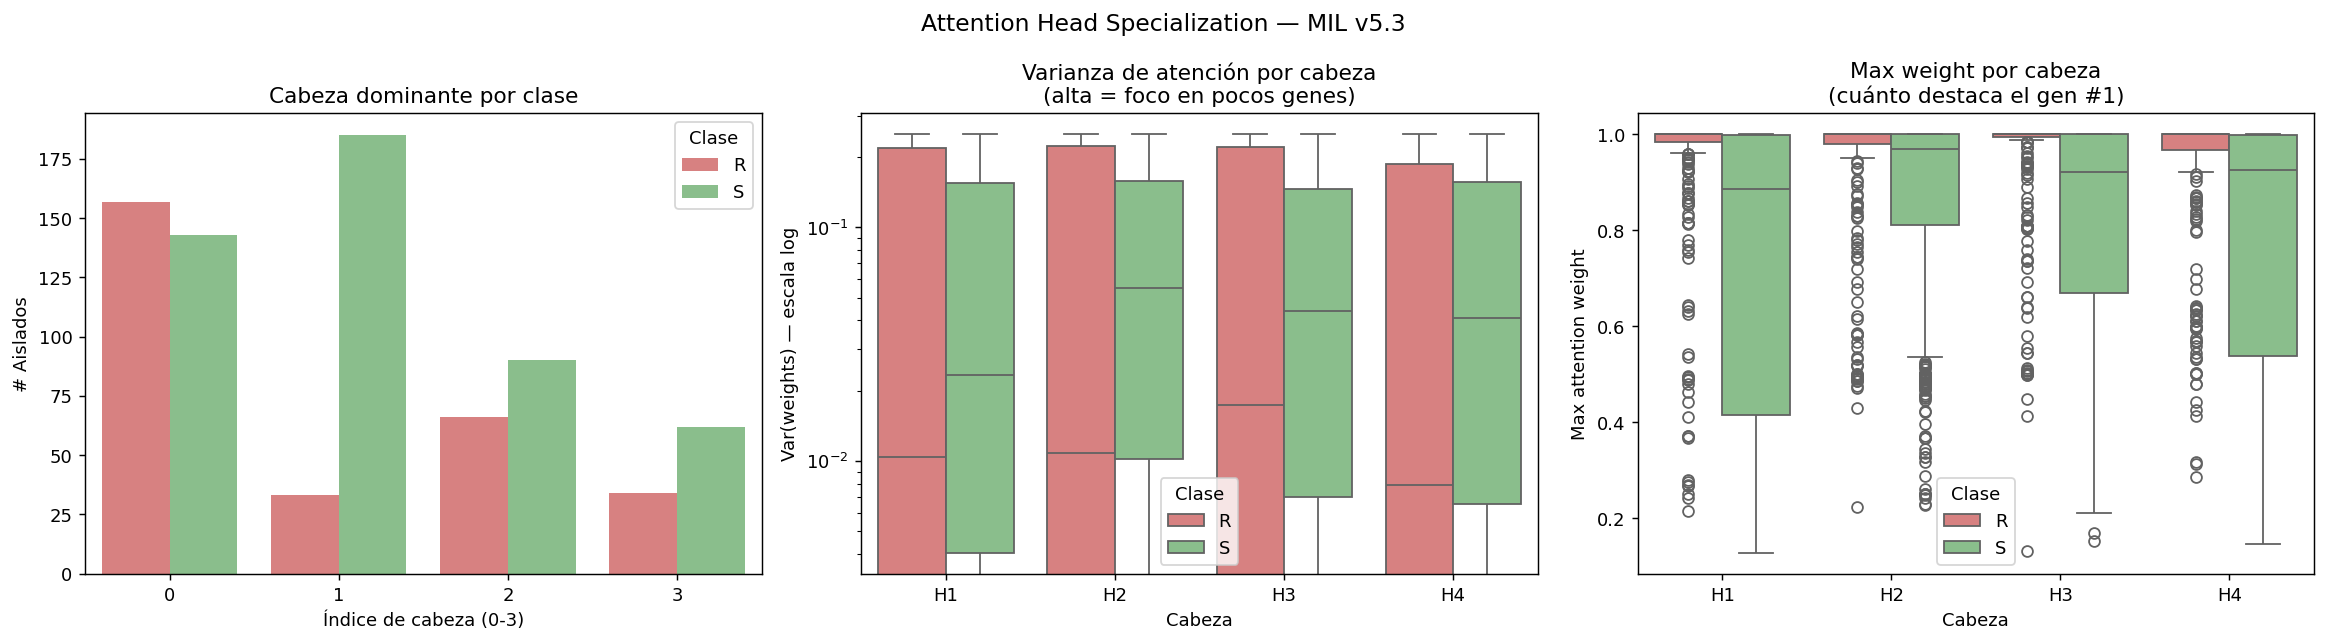

Guardado: head_specialization.png

--- Mann-Whitney U: varianza de atención R vs S por cabeza ---
  H1: U=64204, p=0.0667 ns
  H2: U=62477, p=0.0155 *
  H3: U=65438, p=0.1572 ns
  H4: U=61584, p=0.0064 **


In [ ]:
print("=" * 60)
print("ANÁLISIS C — Attention Head Specialization")
print("=" * 60)

attn_df["Clase"] = attn_df["label"].map({0: "S", 1: "R"})

# --- C1: Cabeza dominante por clase ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(
    data=attn_df, x="dominant_head", hue="Clase",
    palette={"S": "#81C784", "R": "#E57373"}, ax=axes[0]
)
axes[0].set_title("Cabeza dominante por clase")
axes[0].set_xlabel("Índice de cabeza (0-3)")
axes[0].set_ylabel("# Aislados")

# --- C2: Varianza de atención por cabeza y clase ---
var_records = []
for _, row in attn_df.iterrows():
    for h, v in enumerate(row["head_var_weights"]):
        var_records.append({"Cabeza": f"H{h+1}", "Clase": row["Clase"], "Var_Atención": v})
df_var = pd.DataFrame(var_records)

sns.boxplot(
    data=df_var, x="Cabeza", y="Var_Atención", hue="Clase",
    palette={"S": "#81C784", "R": "#E57373"}, ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Varianza de atención por cabeza\n(alta = foco en pocos genes)")
axes[1].set_ylabel("Var(weights) — escala log")

# --- C3: Max weight por cabeza y clase ---
max_records = []
for _, row in attn_df.iterrows():
    for h, v in enumerate(row["head_max_weights"]):
        max_records.append({"Cabeza": f"H{h+1}", "Clase": row["Clase"], "Max_Atención": v})
df_max = pd.DataFrame(max_records)

sns.boxplot(
    data=df_max, x="Cabeza", y="Max_Atención", hue="Clase",
    palette={"S": "#81C784", "R": "#E57373"}, ax=axes[2]
)
axes[2].set_title("Max weight por cabeza\n(cuánto destaca el gen #1)")
axes[2].set_ylabel("Max attention weight")

plt.suptitle("Attention Head Specialization — MIL v5.3", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/head_specialization.png", dpi=150)
plt.show()
print("Guardado: head_specialization.png")

# Test estadístico de diferencia entre R y S en varianza por cabeza
from scipy import stats
print("\n--- Mann-Whitney U: varianza de atención R vs S por cabeza ---")
for h in range(NUM_HEADS):
    r_vals = df_var[(df_var["Cabeza"] == f"H{h+1}") & (df_var["Clase"] == "R")]["Var_Atención"]
    s_vals = df_var[(df_var["Cabeza"] == f"H{h+1}") & (df_var["Clase"] == "S")]["Var_Atención"]
    stat, pval = stats.mannwhitneyu(r_vals, s_vals, alternative="two-sided")
    sig = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else "ns"))
    print(f"  H{h+1}: U={stat:.0f}, p={pval:.4f} {sig}")

---
# ═══════════════════════════════════════════════════
# ANÁLISIS D — Gene Backtracking + BLAST
# SHAP top dims → genes responsables → anotación
# ═══════════════════════════════════════════════════

### D1 — Backtracking: ¿qué genes activan las top dimensiones?

In [ ]:
print(f"Top {TOP_K_DIMS} dims SHAP: {top_dims.tolist()}")

dict_bags_val = {b["genome_id"]: b["sequences"] for b in val_bags}
proj_weight   = modelo.projection.weight.detach()  # [768, 768*NUM_HEADS]

gene_records = []

modelo.eval()
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Gene Backtracking"):
        ids   = batch["input_ids"].squeeze(0).to(device)
        mask  = batch["attention_mask"].squeeze(0).to(device)
        sp    = batch["species_ids"].item()
        label = batch["label"].item()
        gid   = batch["genome_id"][0]
        seqs  = dict_bags_val.get(gid, [])

        with torch.amp.autocast('cuda'):
            embs = encode_bag(modelo, ids, mask, sp)  # [N, 768]
            N    = embs.size(0)

            attn_weights = []
            for attn_net in modelo.attention_heads:
                w = torch.softmax(attn_net(embs), dim=0)
                attn_weights.append(w)

            # Contribución aditiva de cada gen al embedding final [N, 768]
            weighted_embs   = [attn_weights[h] * embs for h in range(NUM_HEADS)]
            concat_weighted = torch.cat(weighted_embs, dim=1)  # [N, 768*NUM_HEADS]
            gene_contribs   = F.linear(concat_weighted, proj_weight)  # [N, 768]

            max_attn_per_gene = torch.stack(
                [attn_weights[h].squeeze(1) for h in range(NUM_HEADS)], dim=1
            ).max(dim=1).values  # [N]

        for i in range(N):
            seq_full = seqs[i] if i < len(seqs) else ""
            rec = {
                "genome_id"    : gid,
                "label"        : label,
                "gene_idx"     : i,
                "max_attention": max_attn_per_gene[i].item(),
                "seq_snippet"  : seq_full[:60] + "..." if len(seq_full) > 60 else seq_full,
                "full_sequence": seq_full,
            }
            for dim in top_dims:
                rec[f"Dim_{dim}_Contrib"] = gene_contribs[i, dim].item()
            gene_records.append(rec)

df_genes = pd.DataFrame(gene_records)
df_genes.to_csv(f"{RUTA_SALIDA}/gene_contributions_top_dims.csv", index=False)
print(f"Guardado: gene_contributions_top_dims.csv ({len(df_genes)} filas)")

Top 5 dims SHAP: [550, 755, 737, 267, 103]


Gene Backtracking:   0%|          | 0/770 [00:00<?, ?it/s]

Guardado: gene_contributions_top_dims.csv (4502 filas)


### D2 — Visualizar activación de top dims por clase


--- TOP 3 GENES activadores Dim 550 ---
  [R] Contrib: 1.5215 | Attn: 1.0000 | GCATCCAAGCAGCAAGCGCGTTACGCCGTGGGTCGATGTTTGATGTTATGGAGCAGCAAC...
  [R] Contrib: 1.5215 | Attn: 1.0000 | GCATCCAAGCAGCAAGCGCGTTACGCCGTGGGTCGATGTTTGATGTTATGGAGCAGCAAC...
  [R] Contrib: 1.5215 | Attn: 1.0000 | GCATCCAAGCAGCAAGCGCGTTACGCCGTGGGTCGATGTTTGATGTTATGGAGCAGCAAC...

--- TOP 3 GENES activadores Dim 755 ---
  [S] Contrib: 0.7104 | Attn: 1.0000 | ATGTCTAGATTAGATAAAAGTAAAGTGATTAACAGCGCATTAGAGCTGCTTAATGAGGTC...
  [S] Contrib: 0.6953 | Attn: 0.9845 | GTGACGGCGGAATTAGATATGTTAATTGAAACTCCAGAATATAAATCAGCCCCCGGACAG...
  [S] Contrib: 0.6455 | Attn: 1.0000 | ATGACTCTAGCGTTAATGGACGAAAAAATTGACAGGAACCGCTTTACTGGGGCGAAAATT...

--- TOP 3 GENES activadores Dim 737 ---
  [S] Contrib: 1.4697 | Attn: 1.0000 | GTGCCGTTGGGTGCACGAGTGGGTTACATCGAACTGGATCTCAACAGCGGTAAGATCCTT...
  [S] Contrib: 1.2969 | Attn: 1.0000 | TTGGCAGCATCACCGAAAAACACAATACATATCAACTTCGCTATTTTTTTAATAATTGCA...
  [S] Contrib: 1.1553 | Attn: 1.0000 | ATGCAACAGCAAAA

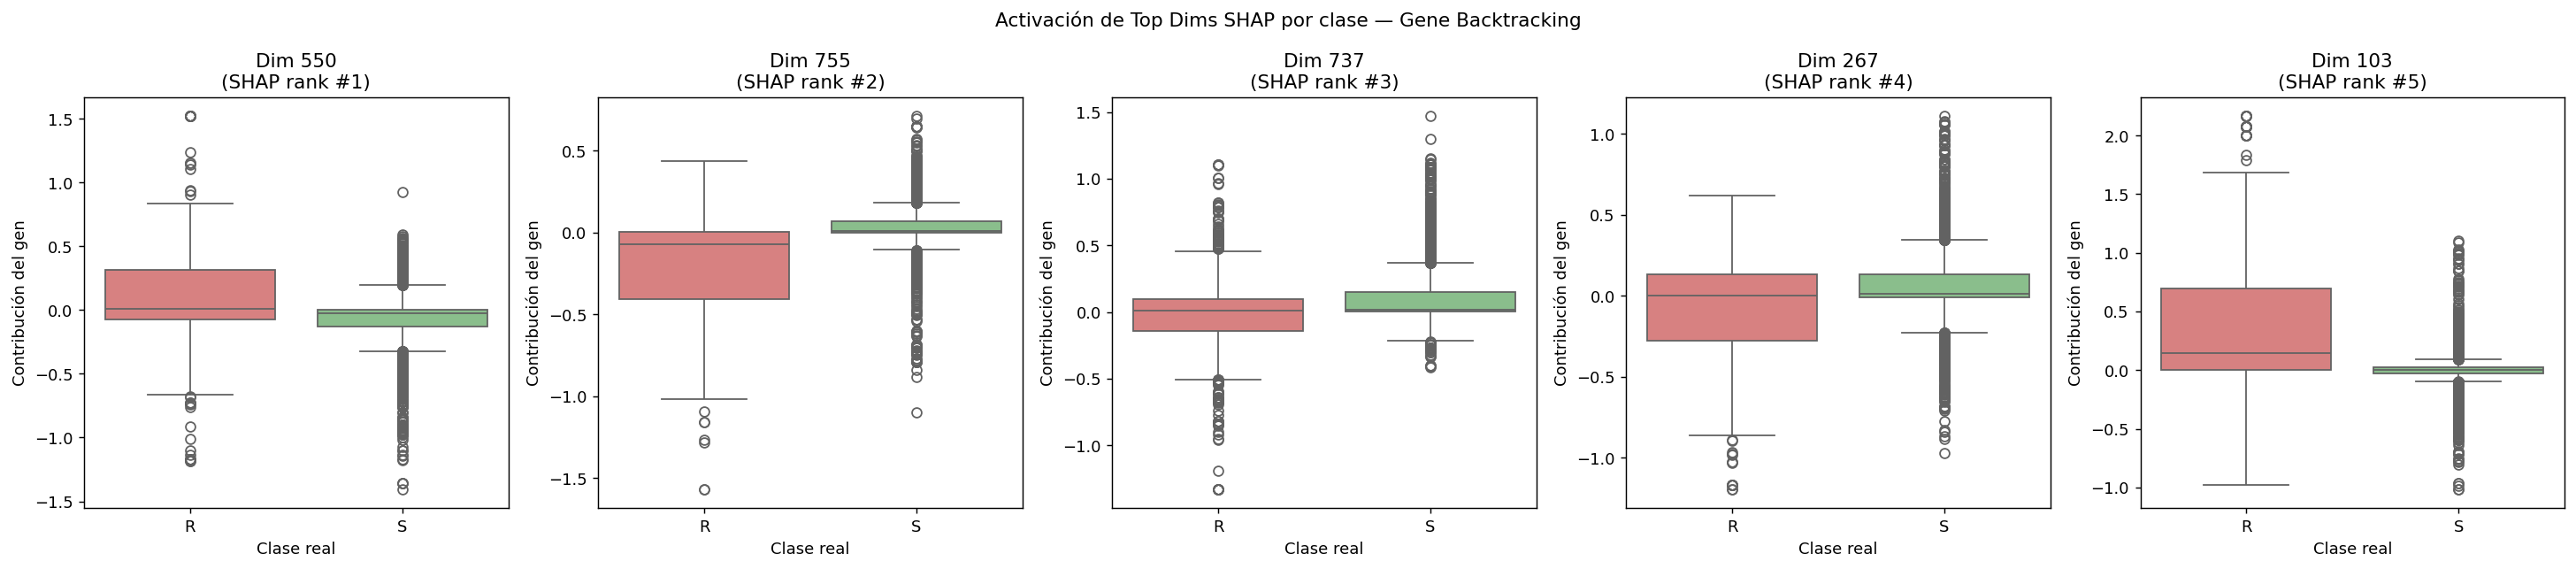

Guardado: gene_backtracking_dims.png


In [ ]:
fig, axes = plt.subplots(1, TOP_K_DIMS, figsize=(4.5 * TOP_K_DIMS, 5))
if TOP_K_DIMS == 1:
    axes = [axes]

for idx, dim in enumerate(top_dims):
    col = f"Dim_{dim}_Contrib"
    df_genes["Clase"] = df_genes["label"].map({0: "S", 1: "R"})
    sns.boxplot(
        data=df_genes, x="Clase", y=col,
        palette={"S": "#81C784", "R": "#E57373"},
        ax=axes[idx], hue="Clase", legend=False
    )
    axes[idx].set_title(f"Dim {dim}\n(SHAP rank #{idx+1})")
    axes[idx].set_xlabel("Clase real")
    axes[idx].set_ylabel("Contribución del gen")

    # Top 3 genes activadores
    top3 = df_genes.nlargest(3, col)
    print(f"\n--- TOP 3 GENES activadores Dim {dim} ---")
    for _, row in top3.iterrows():
        print(f"  [{row['Clase']}] Contrib: {row[col]:.4f} | Attn: {row['max_attention']:.4f} | {row['seq_snippet']}")

plt.suptitle("Activación de Top Dims SHAP por clase — Gene Backtracking", fontsize=12)
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/gene_backtracking_dims.png", dpi=150)
plt.show()
print("Guardado: gene_backtracking_dims.png")

### D3 — Anotación BLAST (NCBI online)
Seleccionamos las top secuencias por dimensión y las enviamos a NCBI BLAST para anotación automática.

In [ ]:
!pip install -q biopython
import time
from Bio.Blast import NCBIWWW, NCBIXML
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from IPython.display import display as ipy_display

TOP_N_PER_DIM = 2  # secuencias únicas por dimensión (no satura la API)

secuencias_blast = []
fasta_records    = []

for dim in top_dims:
    col = f"Dim_{dim}_Contrib"
    if col not in df_genes.columns:
        continue
    top_rows = df_genes.nlargest(TOP_N_PER_DIM * 5, col)
    agregadas = 0
    for _, row in top_rows.iterrows():
        seq = row["full_sequence"]
        if len(seq) < 30:
            continue
        if any(s["seq"] == seq for s in secuencias_blast):
            continue
        clase = "R" if row["label"] == 1 else "S"
        entry = {
            "dim"     : dim,
            "clase"   : clase,
            "contrib" : row[col],
            "attn"    : row["max_attention"],
            "snippet" : row["seq_snippet"],
            "seq"     : seq,
        }
        secuencias_blast.append(entry)
        seq_id = f"Dim{dim}_{clase}_{agregadas+1}"
        fasta_records.append(
            SeqRecord(Seq(seq), id=seq_id, description=f"contrib:{row[col]:.3f}")
        )
        agregadas += 1
        if agregadas >= TOP_N_PER_DIM:
            break

fasta_path = f"{RUTA_SALIDA}/top_seqs_blast.fasta"
SeqIO.write(fasta_records, fasta_path, "fasta")
print(f"FASTA guardado: {fasta_path} ({len(fasta_records)} secuencias)")

# ─── BLAST online ──────────────────────────────────────────────────────────────
print("\nIniciando BLAST online (puede tardar ~2 min por secuencia)...")
RESISTENCIA_KW = [
    "carbapenem", "beta-lactamase", "kpc", "ndm", "oxa", "vim", "imp",
    "efflux", "porin", "omp", "plasmid", "integron", "transposon"
]

for item in tqdm(secuencias_blast, desc="BLAST"):
    try:
        handle  = NCBIWWW.qblast("blastn", "nt", item["seq"], hitlist_size=1)
        record  = NCBIXML.read(handle)
        anotacion = "Sin hits significativos"
        identidad = 0.0
        evalue    = 1.0
        if record.alignments:
            aln = record.alignments[0]
            hsp = aln.hsps[0]
            anotacion = aln.title.split("|")[-1].strip() if "|" in aln.title else aln.title
            identidad = (hsp.identities / hsp.align_length) * 100
            evalue    = hsp.expect
        item["blast_hit"]  = anotacion[:120]
        item["identity"]   = round(identidad, 2)
        item["evalue"]     = evalue
    except Exception as e:
        item["blast_hit"] = f"Error: {e}"
        item["identity"]  = None
        item["evalue"]    = None
    time.sleep(2.5)

df_blast = pd.DataFrame(secuencias_blast)[
    ["dim","clase","contrib","attn","identity","evalue","blast_hit","snippet"]
]
df_blast.to_csv(f"{RUTA_SALIDA}/blast_annotations.csv", index=False)
ipy_display(df_blast)

# Resumen de mecanismos detectados
mechs = set()
for _, row in df_blast[df_blast["clase"]=="R"].iterrows():
    for kw in RESISTENCIA_KW:
        if kw in str(row["blast_hit"]).lower():
            mechs.add(kw.upper())

print("\n=" * 50)
print("RESUMEN BIOLÓGICO")
if mechs:
    print(f"Mecanismos detectados en clase R: {', '.join(mechs)}")
    print("→ El modelo aprendió a usar genes AMR conocidos para predecir resistencia.")
else:
    print("→ No se detectaron keywords AMR estándar. Revisar manualmente las anotaciones.")
    print("  (Posibles plásmidos, genes regulatorios, o mecanismos no convencionales)")
print("=" * 50)
print("Guardado: blast_annotations.csv")

FASTA guardado: ../results/top_seqs_blast.fasta (8 secuencias)

Iniciando BLAST online (puede tardar ~2 min por secuencia)...


BLAST:   0%|          | 0/8 [00:00<?, ?it/s]

,dim,clase,contrib,attn,identity,evalue,blast_hit,snippet
0,550,R,1.521484,1.000000,100.00,0.0,Staphylococcus aureus strain MSE9807 class 1 i...,GCATCCAAGCAGCAAGCGCGTTACGCCGTGGGTCGATGTTTGATGT...
1,755,S,0.710449,0.999992,100.00,0.0,Klebsiella pneumoniae strain 01A17CRGN006 plas...,ATGTCTAGATTAGATAAAAGTAAAGTGATTAACAGCGCATTAGAGC...
2,755,S,0.695312,0.984486,100.00,0.0,Klebsiella pneumoniae strain GDFK0897 chromoso...,GTGACGGCGGAATTAGATATGTTAATTGAAACTCCAGAATATAAAT...
3,737,S,1.469727,1.000000,100.00,0.0,Klebsiella pneumoniae isolate 2025CK-00291 pla...,GTGCCGTTGGGTGCACGAGTGGGTTACATCGAACTGGATCTCAACA...
4,737,S,1.296875,1.000000,100.00,0.0,Klebsiella pneumoniae strain Zagreb038 genome ...,TTGGCAGCATCACCGAAAAACACAATACATATCAACTTCGCTATTT...
5,267,S,1.077148,0.998909,100.00,0.0,Klebsiella pneumoniae strain 180 plasmid unnam...,ATGAAATTGCCCAATATTATTCAACAATTTATTGGAAACAGCGTTT...
6,267,S,1.074219,0.999794,99.97,0.0,"Klebsiella pneumoniae strain KP18 chromosome, ...",ATGCAGGTGTTACCTCCAGGCCGCACCGGCGGCCCGTCCCGGCTGT...
7,103,R,2.166016,1.000000,100.00,0.0,Staphylococcus aureus strain MSE9807 class 1 i...,GCCGTGGGTCGATGTTTGATGTTATGGAGCAGCAACGATGTTACGC...



=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
RESUMEN BIOLÓGICO
Mecanismos detectados en clase R: INTEGRON
→ El modelo aprendió a usar genes AMR conocidos para predecir resistencia.
Guardado: blast_annotations.csv


---
# ═══════════════════════════════════════════════════
# ANÁLISIS E — UMAP de embeddings
# ¿El espacio latente separa bien R de S?
# ═══════════════════════════════════════════════════

Ajustando UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


UMAP listo


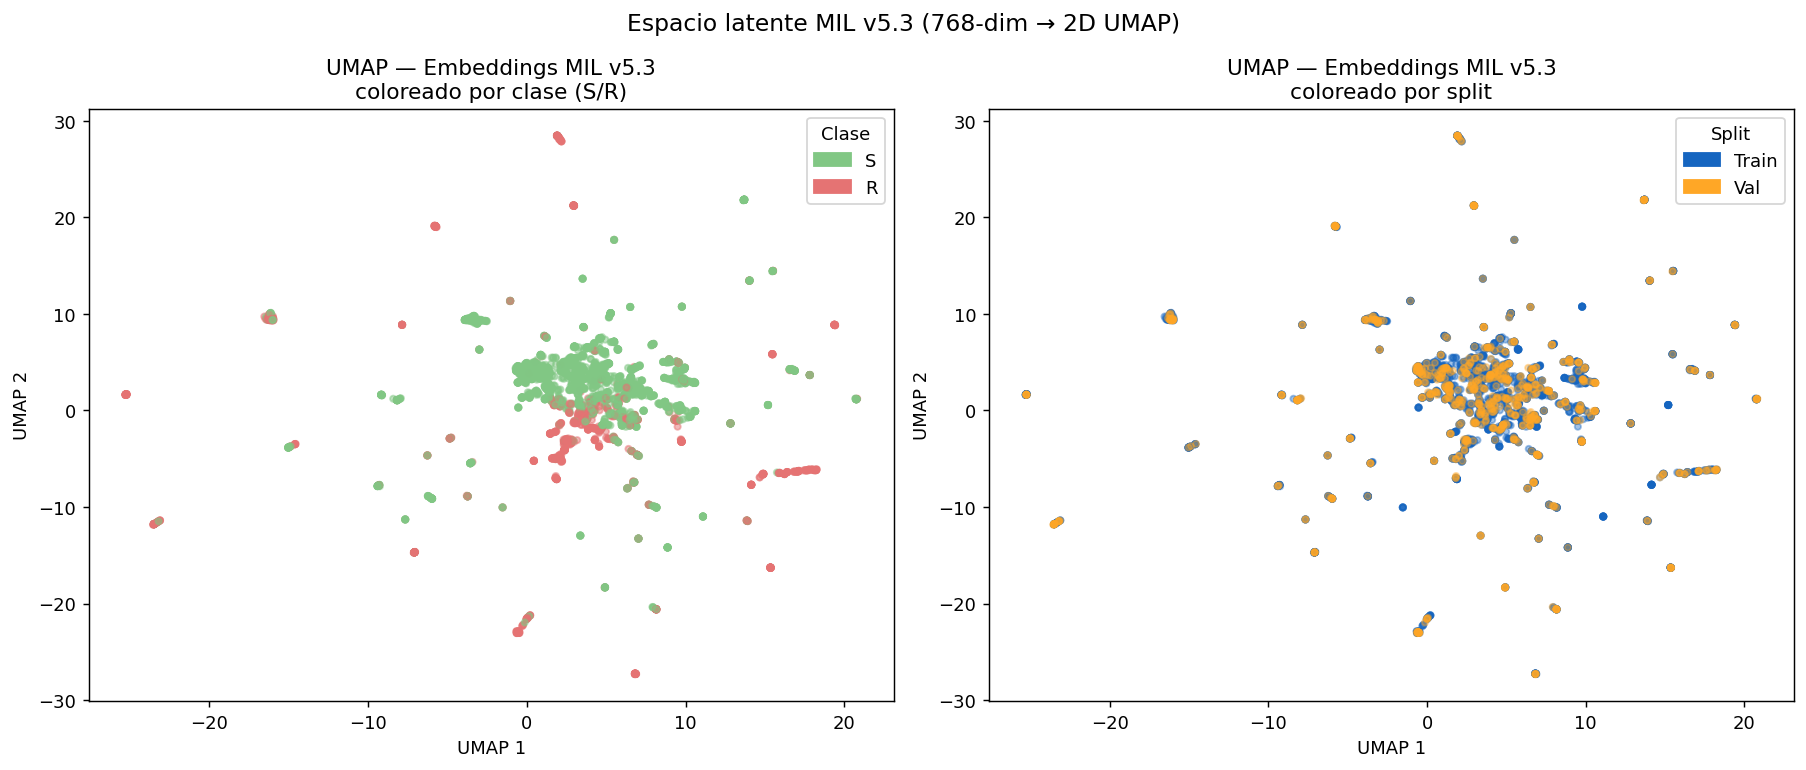

Guardado: umap_embeddings.png


In [ ]:
from umap import UMAP

print("Ajustando UMAP...")
reducer = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)

# Usamos train+val juntos para un UMAP más robusto
X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
split_all = np.array(["Train"] * len(X_train) + ["Val"] * len(X_val))

emb_2d = reducer.fit_transform(X_all)
print("UMAP listo")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: coloreado por label
colors_cls = ["#81C784" if y == 0 else "#E57373" for y in y_all]
axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors_cls, alpha=0.5, s=12)
from matplotlib.patches import Patch
legend_els = [Patch(color="#81C784", label="S"), Patch(color="#E57373", label="R")]
axes[0].legend(handles=legend_els, title="Clase")
axes[0].set_title("UMAP — Embeddings MIL v5.3\ncoloreado por clase (S/R)")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")

# Panel B: coloreado por split train/val
colors_split = ["#1565C0" if s == "Train" else "#FFA726" for s in split_all]
axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors_split, alpha=0.4, s=12)
legend_split = [Patch(color="#1565C0", label="Train"), Patch(color="#FFA726", label="Val")]
axes[1].legend(handles=legend_split, title="Split")
axes[1].set_title("UMAP — Embeddings MIL v5.3\ncoloreado por split")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")

plt.suptitle("Espacio latente MIL v5.3 (768-dim → 2D UMAP)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/umap_embeddings.png", dpi=150)
plt.show()
print("Guardado: umap_embeddings.png")

---
# ═══════════════════════════════════════════════════
# ANÁLISIS F — Precision-Recall + Brier + Calibración
# ═══════════════════════════════════════════════════

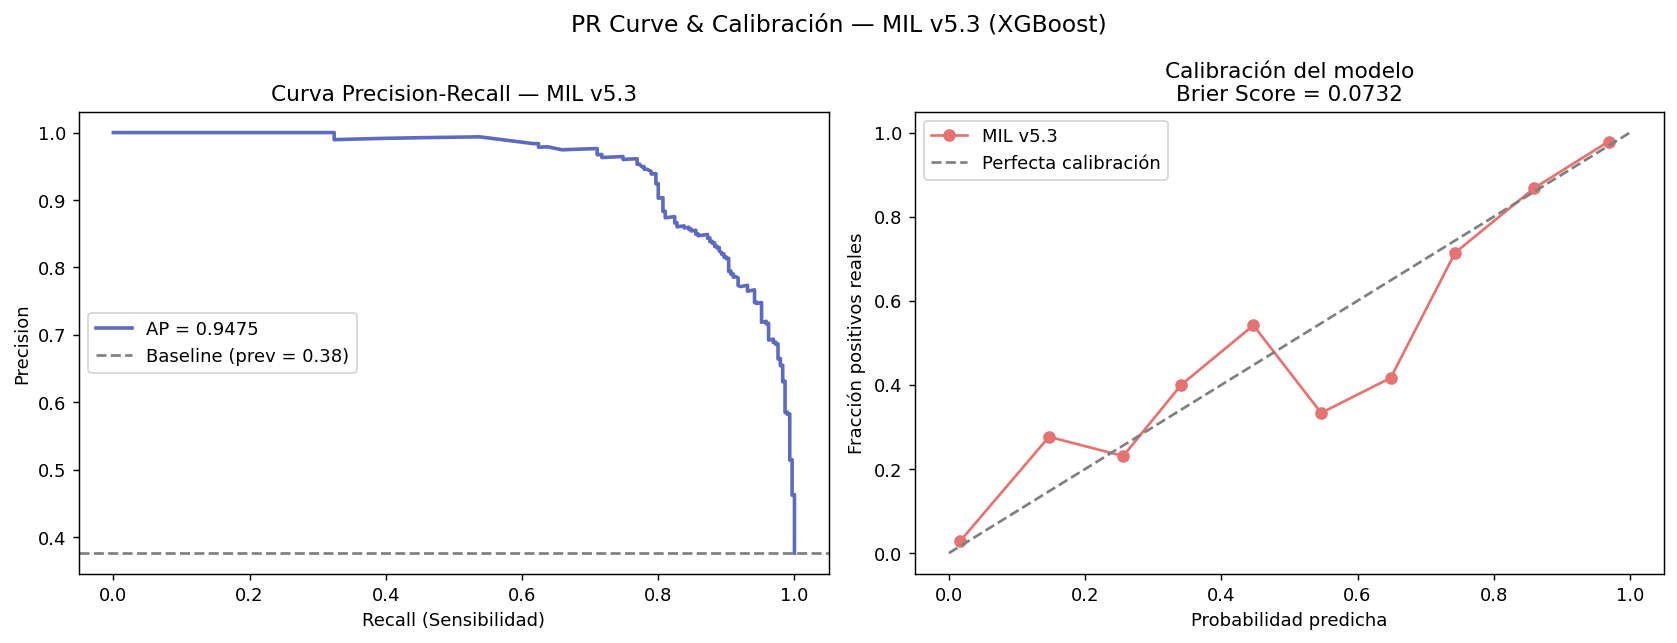

Average Precision: 0.9475
Brier Score      : 0.0732
Guardado: pr_calibration.png


In [ ]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PR Curve
prec, rec, thr_pr = precision_recall_curve(y_val, y_score_val)
ap = average_precision_score(y_val, y_score_val)
axes[0].plot(rec, prec, lw=2, color="#5C6BC0", label=f"AP = {ap:.4f}")
axes[0].axhline(y_val.mean(), color="gray", linestyle="--", label=f"Baseline (prev = {y_val.mean():.2f})")
axes[0].set_xlabel("Recall (Sensibilidad)")
axes[0].set_ylabel("Precision")
axes[0].set_title("Curva Precision-Recall — MIL v5.3")
axes[0].legend()

# Calibration curve
prob_true, prob_pred = calibration_curve(y_val, y_score_val, n_bins=10)
axes[1].plot(prob_pred, prob_true, "o-", label="MIL v5.3", color="#E57373")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Perfecta calibración")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Fracción positivos reales")
axes[1].set_title(f"Calibración del modelo\nBrier Score = {brier_score_loss(y_val, y_score_val):.4f}")
axes[1].legend()

plt.suptitle("PR Curve & Calibración — MIL v5.3 (XGBoost)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{RUTA_SALIDA}/pr_calibration.png", dpi=150)
plt.show()
print(f"Average Precision: {ap:.4f}")
print(f"Brier Score      : {brier_score_loss(y_val, y_score_val):.4f}")
print("Guardado: pr_calibration.png")

---
## Resumen final de archivos generados

In [ ]:
import os

print(f"=== Archivos generados en {RUTA_SALIDA} ===")
for f in sorted(os.listdir(RUTA_SALIDA)):
    fpath = os.path.join(RUTA_SALIDA, f)
    size  = os.path.getsize(fpath)
    print(f"  {f:<50}  {size/1024:.1f} KB")

=== Archivos generados en ../results ===
  blast_annotations.csv                               1.4 KB
  error_analysis_roc.png                              89.5 KB
  gene_backtracking_dims.png                          111.9 KB
  gene_contributions_top_dims.csv                     8610.6 KB
  head_specialization.png                             131.9 KB
  pr_calibration.png                                  114.6 KB
  predictions_val.csv                                 45.9 KB
  sensitivity_LOGO.csv                                8292.5 KB
  sensitivity_LOGO_viz.png                            280.6 KB
  shap_summary_global.png                             215.6 KB
  threshold_sweep.csv                                 0.3 KB
  threshold_sweep.png                                 62.8 KB
  top_seqs_blast.fasta                                9.0 KB
  umap_embeddings.png                                 173.8 KB
